# Análisis de la estacionalidad de la demanda turística
## Pregunta de negocio

¿En qué meses se concentra la demanda turística en los destinos donde opera StaySpain?

Fuente:
Encuesta de Ocupación Hotelera (EOH) - INE

Periodo:
2023-2025

## Objetivo

Analizar la distribución mensual de las pernoctaciones en los destinos donde opera
StaySpain para identificar la existencia de patrones estacionales.

La EOH utiliza las pernoctaciones como principal indicador de demanda turística, este análisis permitirá identificar los meses de mayor actividad
y apoyar decisiones relacionadas con precios, disponibilidad y campañas de marketing.

# 1. Carga de librerías y configuración

In [680]:
import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Carga del dataset

In [681]:
# Parámetros de ejecución
# Parámetros de ejecución

DATASET_FILE = "clean_dataset_INE_EOH_20_07_2026.csv"

fecha_EDA = pd.Timestamp.today().strftime("%d/%m/%Y")

PERIODO_INICIO = pd.Timestamp("2023-01-01")
PERIODO_FIN = pd.Timestamp("2025-12-01")

In [682]:
def encontrar_raiz_proyecto(nombre_carpeta="Equip_34"):
    """
    Busca automáticamente la carpeta raíz del proyecto.
    """
    actual = Path.cwd()

    for carpeta in [actual] + list(actual.parents):
        if carpeta.name == nombre_carpeta:
            return carpeta

    raise FileNotFoundError(
        f"No se encontró la carpeta '{nombre_carpeta}'."
    )


raiz_proyecto = encontrar_raiz_proyecto()

In [683]:
# Ruta del dataset

ruta_csv = (
    raiz_proyecto
    / "Data"
    / DATASET_FILE
)

df = pd.read_csv(
    ruta_csv,
    sep=";",
    encoding="utf-8-sig"
)

print(f"fecha de ejecución: {fecha_EDA}")
print(f"Observaciones : {df.shape[0]:,}")
print(f"Variables     : {df.shape[1]}")

display(df.head())

C:\Users\lacal\AppData\Local\Temp\ipykernel_119108\2622193005.py:9: DtypeWarning: Columns (5,29,30,31,32,33,38,39,40,41,42,43,44,45,46,47) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


fecha de ejecución: 22/07/2026
Observaciones : 1,040,692
Variables     : 48


,tabla,nivel_geo,codigo_ine,geo,geo_key,zona_ccaa,dimension,categoria,categoria_key,metrica,unidad,nivel_jerarquico,periodo,fecha,anio,mes,mes_nombre,mes_nombre_corto,trimestre,anio_mes,orden_anio_mes,anio_completo,periodo_comparacion_2023_2025,periodo_principal_2025,valor,sin_dato,es_dato_no_publicado,provisional,serie_enlazada,mercado_stayspain,tipo_mercado,provincia_referencia,ccaa_referencia,mercados_relacionados,ambito_sprint4,es_demanda_destino,es_procedencia_nacional,es_total_territorial,estancia_media,pct_nacional,pct_extranjero,total_nacional_provincia,valor_estimado_origen,estancia_media_origen,temporada_demanda,ranking_mes_demanda_2023_2025,indice_estacional_base_100,pct_mes_demanda_2023_2025
0,2039,zona_turistica,NaN,Barcelona,barcelona,Cataluña,residencia,Residentes en España,residentes en espana,pernoctaciones,noches,desglose,1999M01,1999-01-01,1999,1,Enero,Ene,T1,1999-01,199901,True,False,False,"179154,0",False,False,False,True,NaN,NaN,NaN,NaN,NaN,False,False,False,False,"2,1406602860522637","40,88360470556018","59,11639529443982",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2039,zona_turistica,NaN,Barcelona,barcelona,Cataluña,residencia,Residentes en España,residentes en espana,pernoctaciones,noches,desglose,1999M02,1999-02-01,1999,2,Febrero,Feb,T1,1999-02,199902,True,False,False,"235791,0",False,False,False,True,NaN,NaN,NaN,NaN,NaN,False,False,False,False,"2,1514955198277277","43,34074700389677","56,65925299610323",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2039,zona_turistica,NaN,Barcelona,barcelona,Cataluña,residencia,Residentes en España,residentes en espana,pernoctaciones,noches,desglose,1999M03,1999-03-01,1999,3,Marzo,Mar,T1,1999-03,199903,True,False,False,"239266,0",False,False,False,True,NaN,NaN,NaN,NaN,NaN,False,False,False,False,"2,191923633631983","37,14872157944094","62,85127842055906",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2039,zona_turistica,NaN,Barcelona,barcelona,Cataluña,residencia,Residentes en España,residentes en espana,pernoctaciones,noches,desglose,1999M04,1999-04-01,1999,4,Abril,Abr,T2,1999-04,199904,True,False,False,"269701,0",False,False,False,True,NaN,NaN,NaN,NaN,NaN,False,False,False,False,"2,2647202069058174","38,50868976703543","61,491310232964565",NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2039,zona_turistica,NaN,Barcelona,barcelona,Cataluña,residencia,Residentes en España,residentes en espana,pernoctaciones,noches,desglose,1999M05,1999-05-01,1999,5,Mayo,May,T2,1999-05,199905,True,False,False,"238228,0",False,False,False,True,NaN,NaN,NaN,NaN,NaN,False,False,False,False,"2,280894250562497","33,362789596850654","66,63721040314935",NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [684]:
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

In [685]:
# Convertir la variable valor a numérica
df["valor"] = (
    df["valor"]
    .astype(str)
    .str.replace(".", "", regex=False)   # elimina separador de miles si existe
    .str.replace(",", ".", regex=False)  # cambia coma decimal por punto
)

df["valor"] = pd.to_numeric(df["valor"], errors="coerce")

# 3. Validación inicial del dataset

In [686]:
print("Información general")

df.info()

Información general
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040692 entries, 0 to 1040691
Data columns (total 48 columns):
 #   Column                         Non-Null Count    Dtype         
---  ------                         --------------    -----         
 0   tabla                          1040692 non-null  int64         
 1   nivel_geo                      1040692 non-null  object        
 2   codigo_ine                     962390 non-null   float64       
 3   geo                            1040692 non-null  object        
 4   geo_key                        1040692 non-null  object        
 5   zona_ccaa                      63168 non-null    object        
 6   dimension                      1040692 non-null  object        
 7   categoria                      1040692 non-null  object        
 8   categoria_key                  1040692 non-null  object        
 9   metrica                        1040692 non-null  object        
 10  unidad                         104

In [687]:
print("Valores nulos")

display(
    df.isna()
      .sum()
      .sort_values(ascending=False))

Valores nulos


temporada_demanda                1031604
ranking_mes_demanda_2023_2025    1031604
indice_estacional_base_100       1031604
pct_mes_demanda_2023_2025        1031604
tipo_mercado                     1031604
mercado_stayspain                1031604
zona_ccaa                         977524
provincia_referencia              925666
mercados_relacionados             924884
ccaa_referencia                   915796
pct_nacional                      803342
pct_extranjero                    803342
estancia_media                    757444
estancia_media_origen             456166
valor_estimado_origen             452444
total_nacional_provincia          415972
valor                              99588
codigo_ine                         78302
mes                                    0
anio                                   0
nivel_jerarquico                       0
unidad                                 0
fecha                                  0
periodo                                0
categoria       

In [688]:
print("Duplicados")

print(
    f"Filas duplicadas: {df.duplicated().sum()}")

Duplicados
Filas duplicadas: 0


In [689]:
print("Variables numéricas")

display(
    df.describe().T)

Variables numéricas


,count,mean,min,25%,50%,75%,max,std
tabla,1040692.0,2069.069796,2039.0,2069.0,2069.0,2074.0,2078.0,8.305695
codigo_ine,962390.0,3347.090928,1.0,15.0,30.0,46.0,50297.0,9585.787652
fecha,1040692,2013-01-27 13:10:58.514142720,1999-01-01 00:00:00,2006-08-01 00:00:00,2013-03-01 00:00:00,2019-10-01 00:00:00,2026-05-01 00:00:00,NaN
anio,1040692.0,2012.621886,1999.0,2006.0,2013.0,2019.0,2026.0,7.772406
mes,1040692.0,6.444777,1.0,3.0,6.0,9.0,12.0,3.456941
orden_anio_mes,1040692.0,201268.633398,199901.0,200608.0,201303.0,201910.0,202605.0,777.153218
valor,941104.0,77006.369903,0.0,1.34,5.68,6175.25,48181913.0,691013.232117


In [690]:
print("Variables categóricas")

display(
    df.describe(include="object").T)

Variables categóricas


,count,unique,top,freq
nivel_geo,1040692,5,provincia,783020
geo,1040692,214,Barcelona,17478
geo_key,1040692,214,barcelona,17478
zona_ccaa,63168,15,Cataluña,17108
dimension,1040692,2,ccaa_procedencia,697480
categoria,1040692,22,Residentes en España,148576
categoria_key,1040692,22,residentes en espana,148576
metrica,1040692,2,pernoctaciones,520346
unidad,1040692,3,porcentaje,697480
nivel_jerarquico,1040692,2,desglose,959758


# 4. Crear las tres vistas del dataset

In [691]:
df_2039 = (
    df[df["tabla"] == 2039]
    .copy())

df_2074 = (
    df[df["tabla"] == 2074]
    .copy())

df_2078 = (
    df[df["tabla"] == 2078]
    .copy())

In [692]:
print("Distribución por tablas")

print(df["tabla"].value_counts())

Distribución por tablas
tabla
2069    697480
2078    141864
2074    138180
2039     63168
Name: count, dtype: int64


# 5. Mercados de StaySpain 

In [693]:
# Mercados donde opera StaySpain

MAPEO_CCAA = {
    "Barcelona": "Cataluña",
    "Girona": "Cataluña",
    "Madrid": "Madrid, Comunidad de",
    "Valencia": "Comunitat Valenciana",
    "Málaga": "Andalucía",
    "Sevilla": "Andalucía",
    "Mallorca": "Balears, Illes",
    "Menorca": "Balears, Illes"
}

MAPEO_PUNTO = {
    "Barcelona": "Barcelona",
    "Madrid": "Madrid",
    "Girona": "Girona",
    "Valencia": "València",
    "Málaga": "Málaga",
    "Sevilla": "Sevilla"
}

MAPEO_ZONA = {
    "Mallorca": "Isla De Mallorca",
    "Menorca": "Isla De Menorca"
}

# 6. Filtrado

In [694]:
# COMUNIDADES AUTÓNOMAS donde opera StaySpain

ccaa_interes = sorted(set(MAPEO_CCAA.values()))

serie_ccaa = (
    df_2074[
        (df_2074["nivel_geo"] == "ccaa")
        &
        (df_2074["geo"].isin(ccaa_interes))
        &
        (df_2074["metrica"] == "pernoctaciones")
        &
        (df_2074["categoria"] == "Total")
        &
        (df_2074["fecha"].between(PERIODO_INICIO, PERIODO_FIN))
    ]
).copy()

serie_ccaa["Comunidad"] = serie_ccaa["geo"]
serie_ccaa["Mes"] = serie_ccaa["fecha"].dt.month


# CIUDADES

ciudades_interes = list(MAPEO_PUNTO.values())

serie_ciudades = (
    df_2078[
        (df_2078["geo"].isin(ciudades_interes))
        &
        (df_2078["metrica"] == "pernoctaciones")
        &
        (df_2078["categoria"] == "Total")
        &
        (df_2078["fecha"].between(PERIODO_INICIO, PERIODO_FIN))
    ]
).copy()

serie_ciudades["Ciudad"] = (
    serie_ciudades["geo"]
        .replace({v: k for k, v in MAPEO_PUNTO.items()})
)

serie_ciudades["Mes"] = serie_ciudades["fecha"].dt.month


# ISLAS

zonas_interes = list(MAPEO_ZONA.values())

serie_islas = (
    df_2039[
        (df_2039["geo"].isin(zonas_interes))
        &
        (df_2039["metrica"] == "pernoctaciones")
        &
        (df_2039["categoria"] == "Total")
        &
        (df_2039["fecha"].between(PERIODO_INICIO, PERIODO_FIN))
    ]
).copy()

serie_islas["Isla"] = (
    serie_islas["geo"]
        .replace({v: k for k, v in MAPEO_ZONA.items()})
)

serie_islas["Mes"] = serie_islas["fecha"].dt.month

## 1. Evolución mensual de las pernoctaciones

En primer lugar se analiza la evolución mensual de las pernoctaciones en las
comunidades autónomas donde opera StaySpain.

Las pernoctaciones representan el número de noches que los viajeros permanecen
alojados y constituyen el indicador más adecuado para estudiar la estacionalidad
de la demanda turística.

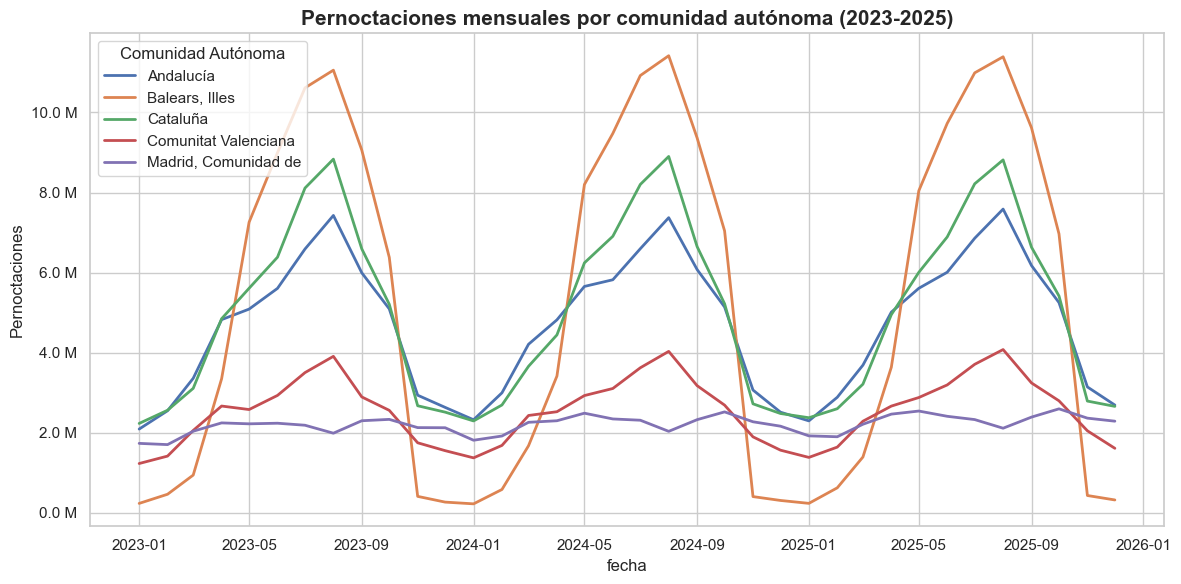

In [695]:
fig, ax = plt.subplots(figsize=(12,6))
for comunidad, grupo in serie_ccaa.groupby("Comunidad"):
    grupo = grupo.sort_values("fecha")
    ax.plot(
        grupo["fecha"],
        grupo["valor"],
        linewidth=2,
        label=comunidad
    )
ax.set_title(
    "Pernoctaciones mensuales por comunidad autónoma (2023-2025)",
    fontsize=15,
    fontweight="bold"
)
ax.set_xlabel("fecha")
ax.set_ylabel("Pernoctaciones")
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x,_: f"{x/1e6:.1f} M"
    )
)

plt.legend(title="Comunidad Autónoma")

plt.tight_layout()

plt.show()

### Interpretación

El gráfico permite observar la evolución temporal de las pernoctaciones en las
cinco comunidades autónomas donde StaySpain desarrolla su actividad.

Se aprecia un comportamiento claramente estacional en la mayoría de destinos,
aunque con intensidades diferentes según la comunidad autónoma.

## 8. Patrón estacional medio (2023-2025)

Para identificar la estacionalidad típica se calcula la media de
pernoctaciones de cada mes durante el periodo 2023-2025.

De esta forma se elimina el efecto de un año concreto y se obtiene
el comportamiento estacional representativo de cada comunidad autónoma.

In [696]:
estacionalidad_media = (
    serie_ccaa
    .groupby(
        ["Comunidad","Mes"]
    )["valor"]
    .mean()
    .reset_index()
)

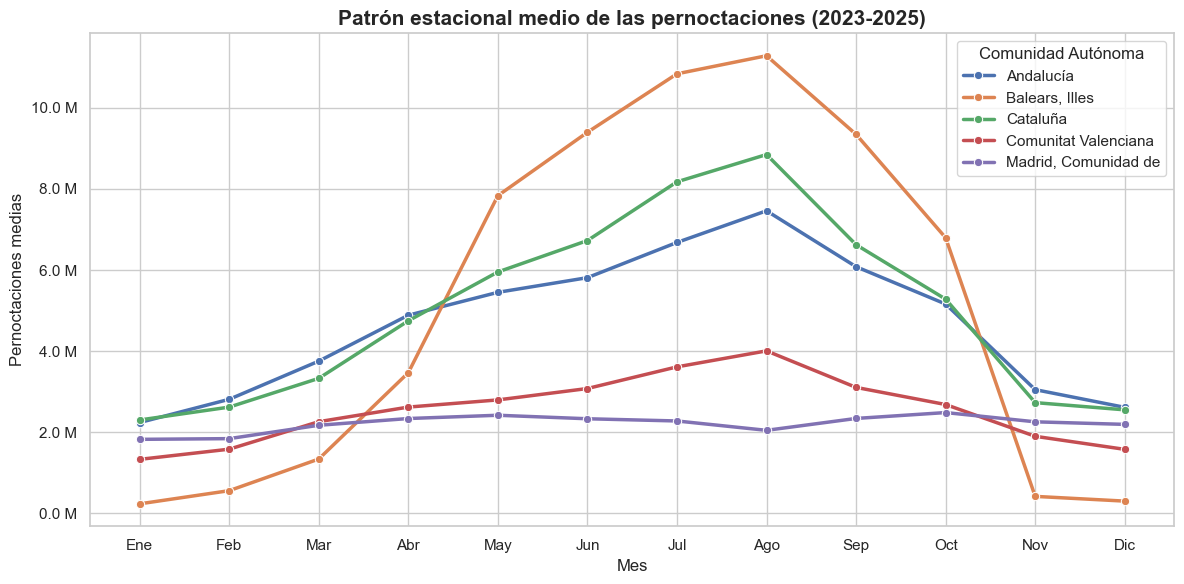

In [697]:
fig, ax = plt.subplots(figsize=(12,6))
sns.lineplot(
    data=estacionalidad_media,
    x="Mes",
    y="valor",
    hue="Comunidad",
    marker="o",
    linewidth=2.5,
    ax=ax
)

ax.set_title(
    "Patrón estacional medio de las pernoctaciones (2023-2025)",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Mes")
ax.set_ylabel("Pernoctaciones medias")
ax.set_xticks(range(1,13))
ax.set_xticklabels([
    "Ene","Feb","Mar","Abr","May","Jun",
    "Jul","Ago","Sep","Oct","Nov","Dic"
])
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x,_:f"{x/1e6:.1f} M"
    )
)
ax.legend(title="Comunidad Autónoma")
plt.tight_layout()
plt.show()

### Interpretación

Al promediar los tres años se observa con mayor claridad el patrón
estacional característico de cada comunidad autónoma.

Illes Balears presenta la mayor concentración de demanda durante los
meses de verano.

Andalucía, Cataluña y Comunitat Valenciana también muestran un fuerte
incremento de las pernoctaciones entre junio y septiembre.

Madrid presenta una evolución más estable a lo largo del año,
con un comportamiento diferente al resto de destinos turísticos.

## 9. Intensidad de la estacionalidad

Se representa la intensidad media de las pernoctaciones mediante un mapa
de calor para facilitar la identificación visual de los meses con mayor
demanda en cada comunidad autónoma.

In [698]:
heatmap = (
    serie_ccaa
    .groupby(
        ["Comunidad","Mes"]
    )["valor"]
    .mean()
    .unstack()
)
heatmap = heatmap.astype("float")

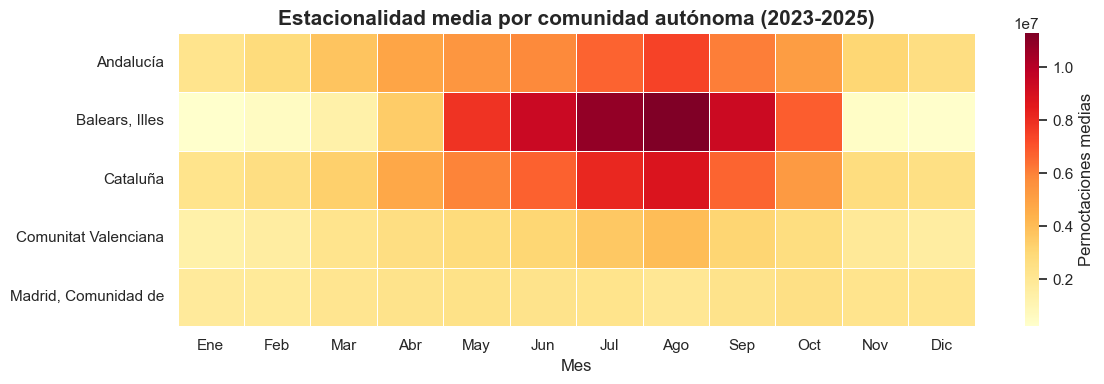

In [699]:
plt.figure(figsize=(12,4))

sns.heatmap(

    heatmap,

    cmap="YlOrRd",

    linewidths=.5,

    cbar_kws={

        "label":"Pernoctaciones medias"

    }

)

plt.title(

    "Estacionalidad media por comunidad autónoma (2023-2025)",

    fontsize=15,

    fontweight="bold"

)

plt.xlabel("Mes")

plt.ylabel("")

plt.xticks(

    np.arange(12)+0.5,

    [

        "Ene","Feb","Mar","Abr","May","Jun",

        "Jul","Ago","Sep","Oct","Nov","Dic"

    ]

)

plt.tight_layout()

plt.show()

### Interpretación

El mapa de calor confirma la existencia de una marcada estacionalidad.

Illes Balears concentra el mayor volumen de pernoctaciones durante los
meses de julio y agosto.

Andalucía, Cataluña y Comunitat Valenciana presentan un patrón muy
similar, aunque menos intenso.

Madrid mantiene una distribución más homogénea durante todo el año,
lo que indica una menor dependencia del turismo estacional.

## 10. Identificación del mes de mayor demanda

Con el objetivo de facilitar la interpretación para negocio, se identifica el
mes con el mayor número medio de pernoctaciones en cada comunidad autónoma.

Este indicador permite conocer cuándo se produce el pico de demanda turística
en los principales mercados donde opera StaySpain.

In [700]:
mes_pico = (

    estacionalidad_media

    .loc[

        estacionalidad_media.groupby("Comunidad")["valor"].idxmax()
    ]
    .sort_values("valor", ascending=False)

)

mes_pico

,Comunidad,Mes,valor
19,"Balears, Illes",8,1.128608e+07
31,Cataluña,8,8.849232e+06
7,Andalucía,8,7.461796e+06
43,Comunitat Valenciana,8,4.007302e+06
57,"Madrid, Comunidad de",10,2.485764e+06


In [701]:
tabla_resumen = (

    mes_pico

    [["Comunidad","Mes","valor"]].rename(columns={
        "Mes":"Mes pico",
        "valor":"Pernoctaciones medias"
    })

)

tabla_resumen

,Comunidad,Mes pico,Pernoctaciones medias
19,"Balears, Illes",8,1.128608e+07
31,Cataluña,8,8.849232e+06
7,Andalucía,8,7.461796e+06
43,Comunitat Valenciana,8,4.007302e+06
57,"Madrid, Comunidad de",10,2.485764e+06


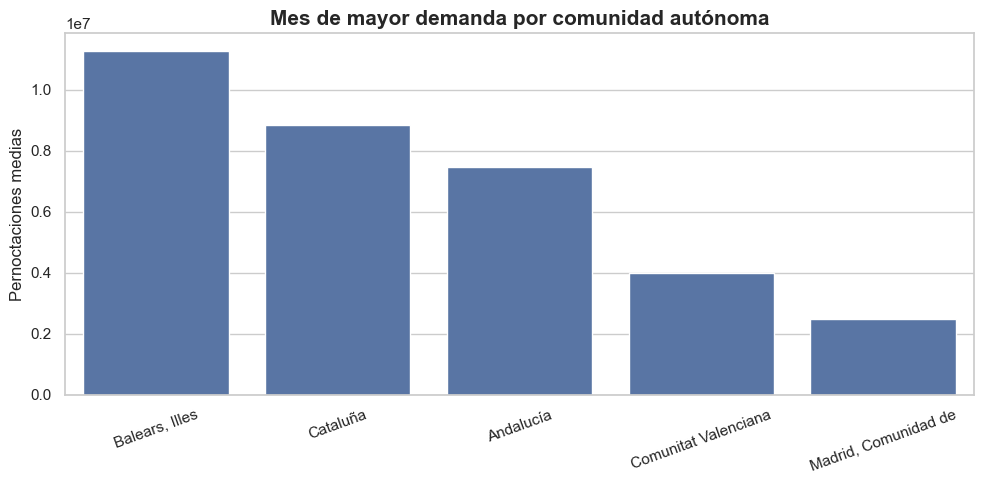

In [702]:
plt.figure(figsize=(10,5))

sns.barplot(

    data=tabla_resumen,

    x="Comunidad",

    y="Pernoctaciones medias"

)

plt.title(

    "Mes de mayor demanda por comunidad autónoma",

    fontsize=15,

    fontweight="bold"

)

plt.ylabel("Pernoctaciones medias")

plt.xlabel("")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

### Interpretación

La mayoría de comunidades presentan su máximo volumen de pernoctaciones durante
los meses estivales.

Illes Balears registra el mayor pico de demanda, seguida de Cataluña y
Andalucía, mientras que Madrid muestra una distribución más equilibrada a lo
largo del año.

## 11. Comparación entre ciudades

In [703]:
serie_ciudades = (

    df_2078
    [
        (df_2078["geo"].isin(MAPEO_PUNTO.values()))
        &
        (df_2078["metrica"] == "pernoctaciones")
        &
        (df_2078["fecha"].between(PERIODO_INICIO,PERIODO_FIN))
    ]
).copy()

In [704]:
serie_ciudades["Ciudad"] = (
    serie_ciudades["geo"]
    .replace({
        v:k
        for k,v in MAPEO_PUNTO.items()
    })
)

serie_ciudades["Mes"] = serie_ciudades["fecha"].dt.month

In [705]:
#patron de estacionalidad 
ciudades_media = (

    serie_ciudades.groupby(
        ["Ciudad","Mes"]
    )["valor"].mean().reset_index())

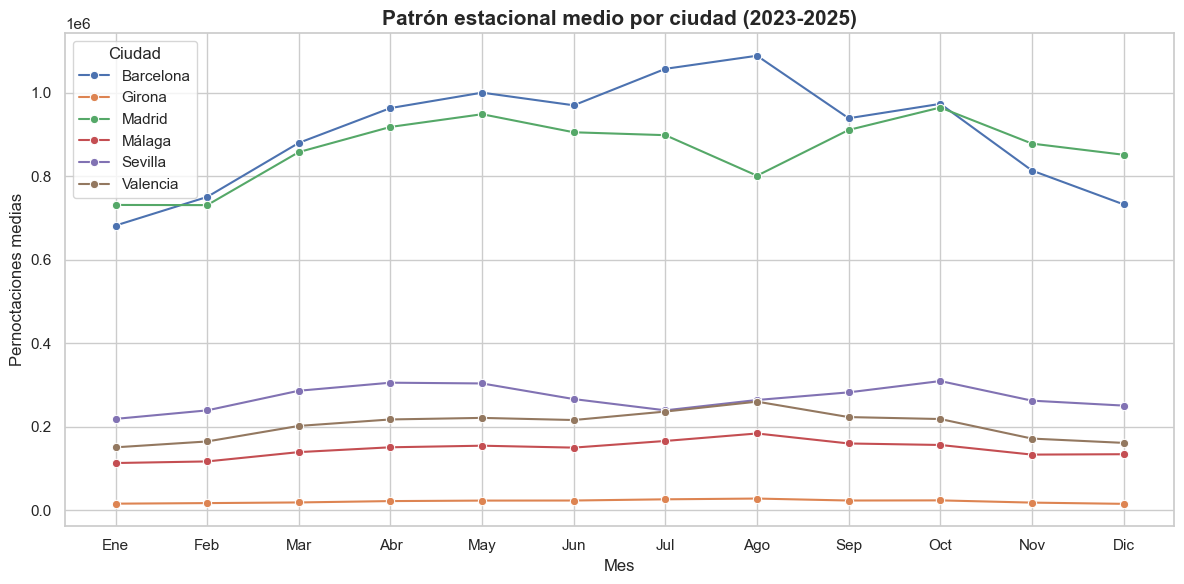

In [706]:
plt.figure(figsize=(12,6))

sns.lineplot(

    data=ciudades_media,
    x="Mes",
    y="valor",
    hue="Ciudad",
    marker="o"
)

plt.title(
    "Patrón estacional medio por ciudad (2023-2025)",
    fontsize=15,
    fontweight="bold"
)

plt.xticks(
    range(1,13),
    [
        "Ene","Feb","Mar","Abr","May","Jun",
        "Jul","Ago","Sep","Oct","Nov","Dic"
    ]
)

plt.xlabel("Mes")
plt.ylabel("Pernoctaciones medias")
plt.tight_layout()

plt.show()

### Interpretación

Las ciudades muestran patrones de demanda diferentes.

Barcelona, Málaga y Valencia presentan una marcada estacionalidad estival,
mientras que Madrid mantiene una demanda más uniforme durante todo el año.

Estas diferencias permiten adaptar estrategias comerciales específicas para
cada destino.

In [707]:
# Tabla resumen
mes_pico_ciudad = (

    ciudades_media.loc[
        ciudades_media
        .groupby("Ciudad")["valor"]
        .idxmax()
]

)

mes_pico_ciudad

,Ciudad,Mes,valor
7,Barcelona,8,1.088306e+06
19,Girona,8,2.744550e+04
33,Madrid,10,9.642435e+05
43,Málaga,8,1.833688e+05
57,Sevilla,10,3.089492e+05
67,Valencia,8,2.596293e+05


## 13. Comparación de la estacionalidad en Mallorca y Menorca

Las Islas Baleares constituyen uno de los principales mercados de StaySpain.
Sin embargo, la intensidad y duración de la temporada turística puede variar
entre Mallorca y Menorca.

En este apartado se analizan las pernoctaciones medias mensuales de ambas islas
para identificar posibles diferencias en su comportamiento estacional.

In [708]:
serie_islas = (

    df_2039

    [(df_2039["geo"].isin(MAPEO_ZONA.values()))
        &
        (df_2039["metrica"]=="pernoctaciones")
        &
        (df_2039["fecha"].between(PERIODO_INICIO,PERIODO_FIN))]

).copy()

In [709]:
serie_islas["Isla"] = (
     serie_islas["geo"].replace({
            v:k
            for k,v in MAPEO_ZONA.items()})

)

serie_islas["Mes"] = serie_islas["fecha"].dt.month

Patrón estacional

In [710]:
# Patrón estacional

In [711]:
islas_media = (
    serie_islas
    .groupby(
       ["Isla","Mes"]
     )["valor"].mean().reset_index()

)

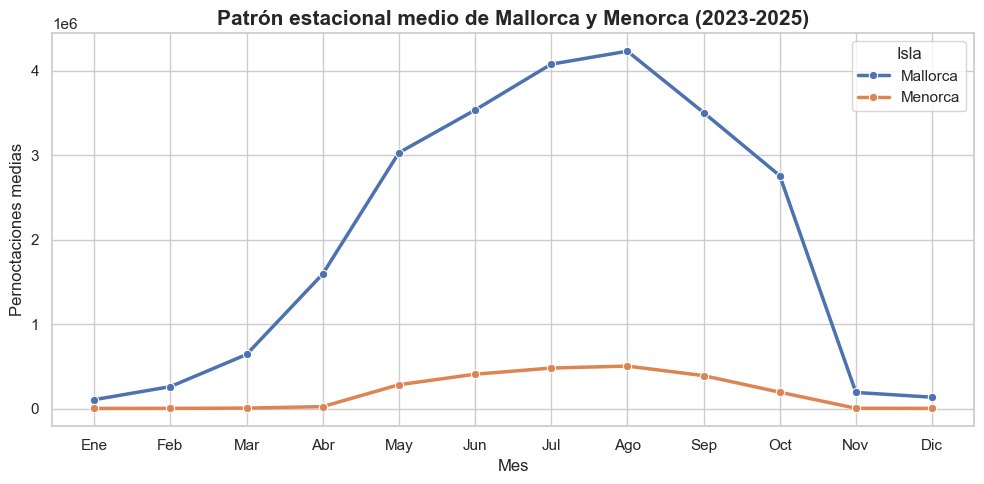

In [712]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=islas_media,
    x="Mes",
    y="valor",
    hue="Isla",
    marker="o",
    linewidth=2.5

)

plt.title(
    "Patrón estacional medio de Mallorca y Menorca (2023-2025)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Mes")
plt.ylabel("Pernoctaciones medias")
plt.xticks(

    range(1,13),
    [
        "Ene","Feb","Mar","Abr","May","Jun",
        "Jul","Ago","Sep","Oct","Nov","Dic"
    ]

)

plt.tight_layout()

plt.show()

### Interpretación

Ambas islas presentan una marcada concentración de la demanda durante los
meses de verano.

No obstante, Mallorca registra un volumen de pernoctaciones
considerablemente superior y mantiene una temporada alta más prolongada,
mientras que Menorca concentra una mayor proporción de su actividad en los
meses centrales del verano.

In [713]:
#tabla resumen
mes_pico_islas = (

    islas_media

    .loc[

        islas_media

        .groupby("Isla")["valor"]

        .idxmax()

    ]

)

mes_pico_islas

,Isla,Mes,valor
7,Mallorca,8,4.232363e+06
19,Menorca,8,5.039625e+05


In [714]:
mes_pico_islas = (

    mes_pico_islas

    [["Isla","Mes","valor"]]

    .rename(columns={

        "Mes":"Mes pico",

        "valor":"Pernoctaciones medias"

    })

)

mes_pico_islas

,Isla,Mes pico,Pernoctaciones medias
7,Mallorca,8,4.232363e+06
19,Menorca,8,5.039625e+05


## Resumen ejecutivo

El análisis de la Encuesta de Ocupación Hotelera (EOH) confirma que la demanda
turística presenta un comportamiento claramente estacional en los principales
mercados donde opera StaySpain.

Los resultados muestran que:

- Illes Balears concentra el mayor volumen de pernoctaciones y presenta la estacionalidad más intensa.
- Andalucía, Cataluña y Comunitat Valenciana también experimentan un fuerte incremento de la demanda durante el verano.
- Madrid mantiene una distribución más homogénea de las pernoctaciones a lo largo del año.
- Mallorca presenta un volumen de demanda superior al de Menorca y una temporada alta más prolongada.

Estos resultados proporcionan información útil para adaptar la planificación de
la oferta, optimizar la disponibilidad de los alojamientos y diseñar campañas
comerciales ajustadas al comportamiento estacional de cada destino.

## Conclusiones

El análisis de las pernoctaciones mensuales de la Encuesta de Ocupación Hotelera (EOH) permite identificar los meses en los que se concentra la demanda turística en los principales destinos donde opera StaySpain.

Los resultados muestran una marcada estacionalidad en la mayoría de los destinos analizados. Illes Balears presenta la mayor concentración de demanda durante los meses de verano, mientras que Andalucía, Cataluña y Comunitat Valenciana también experimentan un incremento significativo entre junio y septiembre.

En cambio, Madrid mantiene una distribución más homogénea de la demanda a lo largo del año, con una menor dependencia de la temporada estival.

A nivel insular, Mallorca registra un mayor volumen de pernoctaciones y una temporada alta más prolongada que Menorca, aunque ambas concentran su demanda en los meses centrales del verano.

En conjunto, el análisis confirma que la demanda turística no se distribuye de forma uniforme durante el año y permite identificar los periodos de mayor concentración de visitantes en cada destino.

#  5. ¿Está alineada la oferta de StaySpain con la demanda turística en cada destino?

En esta sección se incorpora el dataset de StaySpain para comparar laestacionalidad observada en la demanda turística (EOH) con las características de la oferta disponible en la plataforma.

¿La oferta de StaySpain está alineada con esa demanda?

In [715]:
# Localizar la raíz del proyecto
raiz_proyecto = encontrar_raiz_proyecto("Equip_34")

ruta_stayspain = (
    raiz_proyecto /
    "Data" /
    "clean_dataset_13_07_2026.csv"
)

df_stay = pd.read_csv(ruta_stayspain)

print(df_stay.shape)
df_stay.head()

(9650, 54)


,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,beds,amenities_list,price_€,minimum_nights,maximum_nights,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,first_review_date,last_review_date,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,is_instant_bookable,reviews_per_month,country,city,insert_date,has_availability_numeric,rating_above_80,occupancy_30,occupancy_rate_30,occupancy_60,occupancy_rate_60,occupancy_90,occupancy_rate_90,occupancy_365,occupancy_rate_365,is_instant_bookable_numeric,cat_premium,cat_confort,cat_conectividad,cat_familia,cat_seguridad,cat_parking,cat_cocina,logp
0,11411444,Cute apartment close to Pg.Gr�cia a,Cute apartment in Gracia! near Metro Diagonal...,14368366,la Vila de Gr�cia,Gr�cia,Entire home/apt,2,1.0,1.0,1.0,"TV,Wifi,Air conditioning,Kitchen,Heating,Famil...",750.0,3,1125,NaN,29,59,89,364,13,2016-04-16,2016-11-25,83.0,9.0,9.0,9.0,10.0,9.0,9.0,FALSO,147.0,spain,Barcelona,2017-01-04,NaN,True,1,3.33,1,1.67,1,1.11,1,0.27,0,0,1,1,1,0,0,1,6.620073
1,11002274,RAMBLAS APARTMENT ONE BEDROOM,Renovated one bedroom apartment located in th...,383697,el Raval,Ciutat Vella,Entire home/apt,4,1.0,1.0,2.0,"TV,Internet,Wifi,Air conditioning,Kitchen,Fami...",990.0,3,1125,NaN,22,32,57,319,11,2016-02-28,2016-11-27,87.0,9.0,9.0,9.0,9.0,10.0,9.0,VERDADERO,105.0,spain,Barcelona,2017-01-04,NaN,True,8,26.67,28,46.67,33,36.67,46,12.60,1,0,1,1,1,0,0,1,6.897705
2,15254167,"Zona centro, Espacio acogedor, Ambiente tranqu...",Te va a encantar mi lugar debido a el espacio ...,97013848,Hostafrancs,Sants-Montju�c,Private room,1,2.0,1.0,1.0,"Wifi,Kitchen,Elevator in building,Washer,Essen...",320.0,1,1125,NaN,26,56,86,361,9,2016-10-02,2016-12-19,80.0,9.0,8.0,9.0,9.0,10.0,8.0,VERDADERO,284.0,spain,Barcelona,2017-01-04,NaN,False,4,13.33,4,6.67,4,4.44,4,1.10,1,0,1,1,0,0,0,1,5.768321
3,16272738,Comfortable double bedroom Parc G�ell,"Cerca del Barrio de Gracia, Parc G�ell i Sagra...",13952311,el Baix Guinard�,Horta-Guinard�,Private room,2,2.0,1.0,1.0,"TV,Wifi,Kitchen,Smoking allowed,Breakfast,Elev...",760.0,2,1125,NaN,27,55,85,360,1,2017-01-02,2017-01-02,100.0,10.0,10.0,10.0,8.0,8.0,8.0,VERDADERO,10.0,spain,Barcelona,2017-01-04,NaN,True,3,10.00,5,8.33,5,5.56,5,1.37,1,0,1,1,1,1,0,1,6.633318
4,1198074,005596_APARTAMENTO DE 2 DORMITORIOS,!!!-ATTENTION-!!! HERE YOU HAVE THE CHANCE FOR...,6544866,la Dreta de l'Eixample,Eixample,Entire home/apt,4,2.0,2.0,3.0,"TV,Cable TV,Internet,Wifi,Air conditioning,Kit...",2000.0,1,1125,NaN,16,19,29,152,4,2016-03-07,2016-08-07,95.0,10.0,10.0,10.0,10.0,10.0,10.0,VERDADERO,39.0,spain,Barcelona,2017-01-04,NaN,True,14,46.67,41,68.33,61,67.78,213,58.36,1,0,1,1,1,1,0,1,7.600902


In [716]:
# Resumen de la oferta por ciudad
oferta = (
    df_stay
    .groupby("city")
    .agg(
        alojamientos=("apartment_id","nunique"),
        ocupacion_media=("occupancy_rate_365","mean"),
        precio_medio=("price_€","mean"),
        rating=("review_scores_rating","mean")
    )
    .round(2)
    .reset_index()
)
oferta

,city,alojamientos,ocupacion_media,precio_medio,rating
0,Barcelona,2719,49.78,830.15,90.67
1,Girona,1485,46.14,1200.62,90.94
2,Madrid,2134,54.65,791.39,92.63
3,Mallorca,1583,41.39,1655.87,92.97
4,Menorca,218,45.19,1651.16,93.36
5,Málaga,504,45.31,746.04,92.20
6,Sevilla,494,46.23,943.56,93.53
7,Valencia,513,53.43,658.65,92.22


In [717]:
demanda_ciudades = (
    serie_ciudades
    .groupby("Ciudad", as_index=False)
    .agg(
        demanda_media=("valor", "mean")
    )
)

demanda_ciudades

,Ciudad,demanda_media
0,Barcelona,903828.291667
1,Girona,20667.104167
2,Madrid,866016.500000
3,Málaga,145992.041667
4,Sevilla,268509.236111
5,Valencia,203098.708333


In [718]:
demanda_islas = (
    serie_islas
    .groupby("Isla", as_index=False)
    .agg(
        demanda_media=("valor", "mean")
    )
)

demanda_islas

,Isla,demanda_media
0,Mallorca,2.005824e+06
1,Menorca,2.298073e+05


In [719]:
# Unir ciudades e islas
demanda_islas = demanda_islas.rename(
    columns={"Isla": "Ciudad"}
)

demanda_total = pd.concat(
    [
        demanda_ciudades,
        demanda_islas
    ],
    ignore_index=True
)

demanda_total

,Ciudad,demanda_media
0,Barcelona,9.038283e+05
1,Girona,2.066710e+04
2,Madrid,8.660165e+05
3,Málaga,1.459920e+05
4,Sevilla,2.685092e+05
5,Valencia,2.030987e+05
6,Mallorca,2.005824e+06
7,Menorca,2.298073e+05


In [720]:
comparacion = (
    demanda_total
    .merge(
        oferta,
        left_on="Ciudad",
        right_on="city",
        how="inner"
    )
)

comparacion

,Ciudad,demanda_media,city,alojamientos,ocupacion_media,precio_medio,rating
0,Barcelona,9.038283e+05,Barcelona,2719,49.78,830.15,90.67
1,Girona,2.066710e+04,Girona,1485,46.14,1200.62,90.94
2,Madrid,8.660165e+05,Madrid,2134,54.65,791.39,92.63
3,Málaga,1.459920e+05,Málaga,504,45.31,746.04,92.20
4,Sevilla,2.685092e+05,Sevilla,494,46.23,943.56,93.53
5,Valencia,2.030987e+05,Valencia,513,53.43,658.65,92.22
6,Mallorca,2.005824e+06,Mallorca,1583,41.39,1655.87,92.97
7,Menorca,2.298073e+05,Menorca,218,45.19,1651.16,93.36


In [721]:
comparacion["demanda_millones"] = (
    comparacion["demanda_media"] / 1_000_000
).round(2)

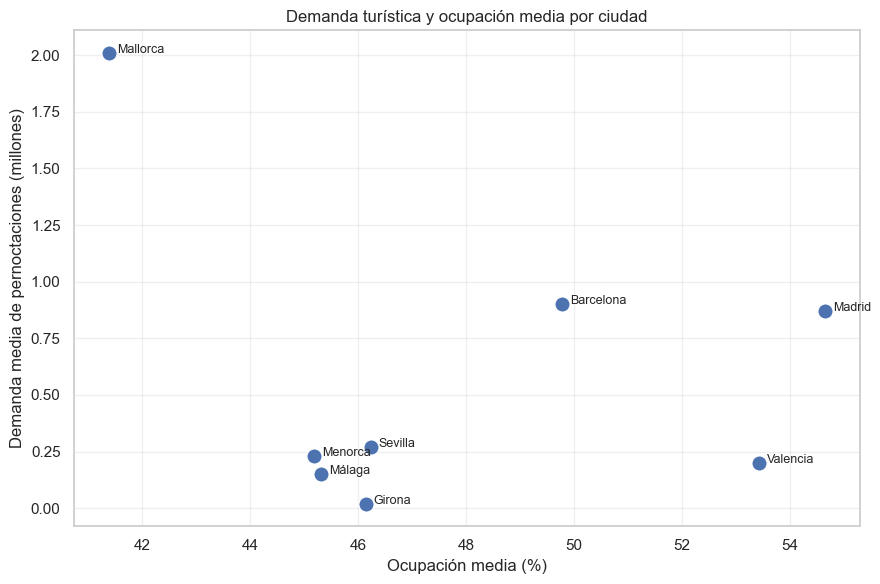

In [722]:
# Relación entre demanda turística y ocupación media

plt.figure(figsize=(9,6))

sns.scatterplot(
    data=comparacion,
    x="ocupacion_media",
    y="demanda_millones",
    s=120
)

for _, fila in comparacion.iterrows():
    plt.text(
        fila["ocupacion_media"] + 0.15,
        fila["demanda_millones"],
        fila["Ciudad"],
        fontsize=9
    )

plt.title("Demanda turística y ocupación media por ciudad")
plt.xlabel("Ocupación media (%)")
plt.ylabel("Demanda media de pernoctaciones (millones)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [723]:
comparacion.sort_values(
    "demanda_media",
    ascending=False
)

,Ciudad,demanda_media,city,alojamientos,ocupacion_media,precio_medio,rating,demanda_millones
6,Mallorca,2.005824e+06,Mallorca,1583,41.39,1655.87,92.97,2.01
0,Barcelona,9.038283e+05,Barcelona,2719,49.78,830.15,90.67,0.90
2,Madrid,8.660165e+05,Madrid,2134,54.65,791.39,92.63,0.87
4,Sevilla,2.685092e+05,Sevilla,494,46.23,943.56,93.53,0.27
7,Menorca,2.298073e+05,Menorca,218,45.19,1651.16,93.36,0.23
5,Valencia,2.030987e+05,Valencia,513,53.43,658.65,92.22,0.20
3,Málaga,1.459920e+05,Málaga,504,45.31,746.04,92.20,0.15
1,Girona,2.066710e+04,Girona,1485,46.14,1200.62,90.94,0.02


Los resultados muestran que la demanda turística y la ocupación media no mantienen una relación directa en todos los destinos donde opera StaySpain. Mallorca destaca como el destino con mayor volumen de pernoctaciones según la EOH, aunque su ocupación media es inferior a la de Madrid y Valencia. Por su parte, Madrid presenta la mayor ocupación media de los alojamientos de StaySpain pese a registrar una demanda inferior a la de Mallorca y similar a la de Barcelona. Estos resultados indican que una mayor demanda turística no implica necesariamente una mayor ocupación de los alojamientos, por lo que la estrategia comercial debe adaptarse a las características específicas de cada destino.

¿Es necesario ajustar nuestras ofertas al perfil del viajero y a la demanda de pernoctaciones...?

Sí. Los datos oficiales permiten identificar dónde y cuándo se concentra la demanda turística, mientras que los datos de StaySpain muestran cómo se comporta la oferta en esos mismos destinos. La combinación de ambas fuentes indica que la estrategia no debería ser uniforme entre comunidades, sino adaptarse a las características de la demanda y al rendimiento de la oferta en cada mercado.